In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%%capture
%run '/content/drive/MyDrive/Repos/MachineLearning-ML001/helper/helper.ipynb'
%run '/content/drive/MyDrive/Repos/MachineLearning-ML001/01 Simple Classification Algorithms/1.2.Adaline.ipynb'

### **Improving Gradient Descent via Feature Scaling (Standardization)**

Gradient descent converges much faster and more reliably when the dataset's features are on the same scale. If features are on vastly different scales, a learning rate ($\eta$) that updates one weight well might be too large or too small for another, causing the optimizer to struggle.

**What is Standardization?**
Standardization is a scaling technique that centers features around a mean of zero and scales them to have a standard deviation of 1 (unit variance).

> **Note:** This procedure does *not* magically make your dataset normally distributed; it merely shifts and scales the values.

**The Formula**
To standardize the $j$th feature, subtract the sample mean ($\mu_j$) and divide by the standard deviation ($\sigma_j$):

$$x_j^{\prime} = \frac{x_j - \mu_j}{\sigma_j}$$

**Visual Intuition (The Loss Surface)**
* **Unscaled Features:** The loss surface looks like an elongated oval. The optimizer has to take a zig-zag, inefficient path to reach the global minimum.
* **Standardized Features:** The loss surface becomes neat, symmetrical concentric circles. The optimizer can take a much more direct, stabilized path to the center (the global loss minimum) in fewer steps.

<p align="center">
  <img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch02/figures/02_13.png" width="600">
</p>

In [ ]:
# standardize features
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

In [ ]:
ada_gd = AdalineGD(n_iter=20, eta=0.5)
ada_gd.fit(X_std, y)

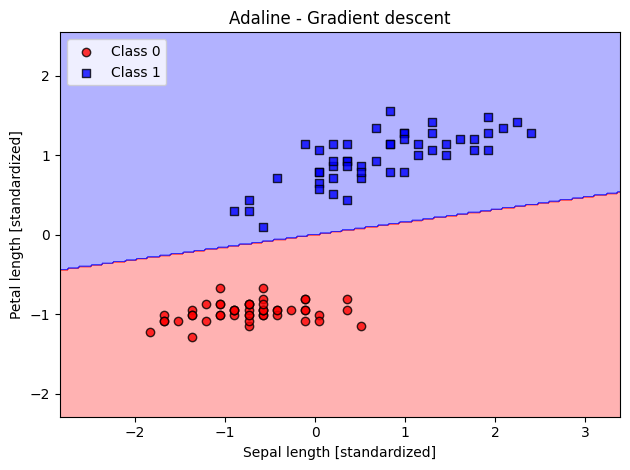

In [ ]:
plot_decision_regions(X_std, y, classifier=ada_gd)
plt.title('Adaline - Gradient descent')
plt.xlabel('Sepal length [standardized]')
plt.ylabel('Petal length [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

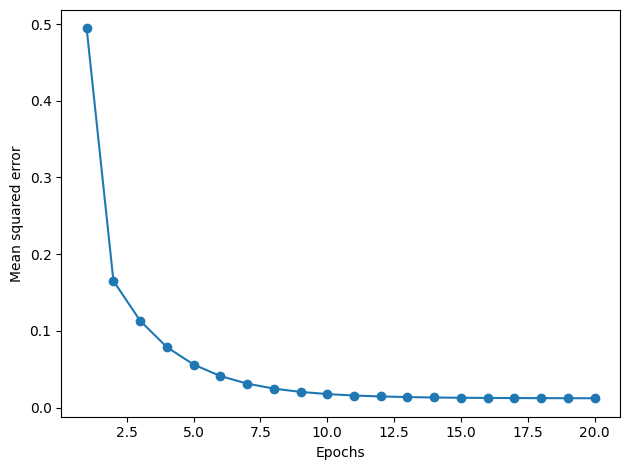

In [ ]:
plt.plot(range(1, len(ada_gd.losses_) + 1), ada_gd.losses_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Mean squared error')

plt.tight_layout()
plt.show()